# Day 18: Matplotlib Basics - Line, Scatter, and Bar Plots
### Foundations of Data Visualization for AI and ML

**Day 18 of the 369-Day Python and AI Learning Path**

## Why Data Visualization Matters in AI and ML

Data visualization bridges raw numbers and real understanding. In artificial intelligence and machine learning, we often work with large datasets, complex models, and high-dimensional patterns. Clear visualizations help us explore data, spot issues, explain model behavior, and communicate findings effectively.

**Understanding distributions:** Before training a model, it is important to understand how features are distributed. Visual tools such as histograms and density plots help reveal skewness, spread, and unusual structure.

**Spotting patterns and outliers:** Scatter plots, line plots, and grouped charts can expose trends, clusters, and anomalies that may not be obvious from summary statistics alone.

**Debugging models:** Training and validation curves make it easier to diagnose underfitting, overfitting, and unstable learning behavior.

**Communicating results:** Well-designed plots can explain model performance more clearly than tables of raw metrics.


## Table of Contents

1. [Introduction to Matplotlib](#intro)
2. [Line Plots](#line)
3. [Scatter Plots](#scatter)
4. [Bar Plots](#bar)
5. [Customization and Styling](#custom)
6. [Multiple Subplots](#subplots)
7. [Saving Figures](#save)
8. [Best Practices](#best)
9. [Real ML Examples](#ml)
10. [Hands-On Exercises](#exercises)
11. [Solutions](#solutions)


## 1. Introduction to Matplotlib {#intro}

Matplotlib is Python's foundational plotting library. It supports two common styles:
- **Pyplot interface (`plt`)**: Quick and convenient for simple plots
- **Object-oriented interface (`fig, ax`)**: More explicit and better for complex figures

The object-oriented approach is usually preferred because it gives you precise control over the figure and its axes.


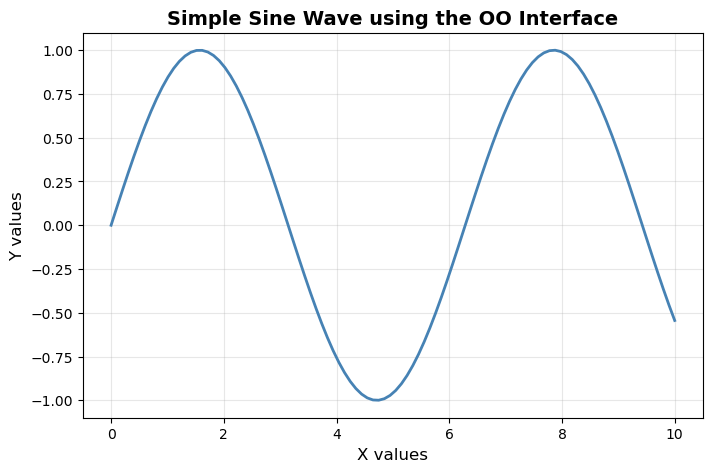

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, color='steelblue', linewidth=2)
ax.set_title('Simple Sine Wave using the OO Interface', fontsize=14, fontweight='bold')
ax.set_xlabel('X values', fontsize=12)
ax.set_ylabel('Y values', fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()


## 2. Line Plots {#line}

Line plots connect data points with straight lines. They are ideal for:
- Time series data
- Continuous mathematical functions
- Training curves such as loss vs. epochs
- Trends over ordered categories

**Useful parameters:**
- `color` or `c`
- `linestyle` or `ls`
- `marker`
- `linewidth` or `lw`
- `markersize`
- `alpha`


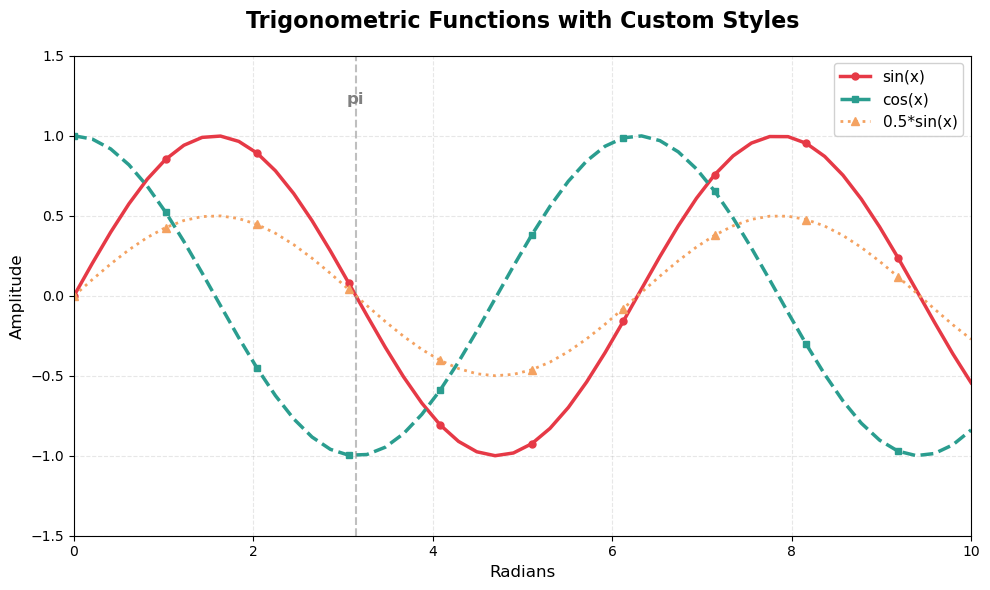

In [2]:
x = np.linspace(0, 10, 50)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, np.sin(x), color='#E63946', linestyle='-', linewidth=2.5,
        marker='o', markersize=5, markevery=5, label='sin(x)')
ax.plot(x, np.cos(x), color='#2A9D8F', linestyle='--', linewidth=2.5,
        marker='s', markersize=5, markevery=5, label='cos(x)')
ax.plot(x, np.sin(x) * 0.5, color='#F4A261', linestyle=':', linewidth=2,
        marker='^', markersize=6, markevery=5, label='0.5*sin(x)')

ax.set_title('Trigonometric Functions with Custom Styles', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Radians', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.legend(loc='upper right', framealpha=0.9, fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 1.5)

ax.axvline(x=np.pi, color='gray', linestyle='--', alpha=0.5)
ax.text(np.pi, 1.2, 'pi', ha='center', fontsize=12, color='gray', fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Scatter Plots {#scatter}

Scatter plots show the relationship between two variables using points. They are especially useful for:
- Exploring correlation between features
- Visualizing clusters
- Inspecting class separation
- Identifying outliers

**Useful parameters:**
- `s` for marker size
- `c` for color
- `cmap` for colormap
- `alpha` for transparency
- `edgecolors` for point outlines


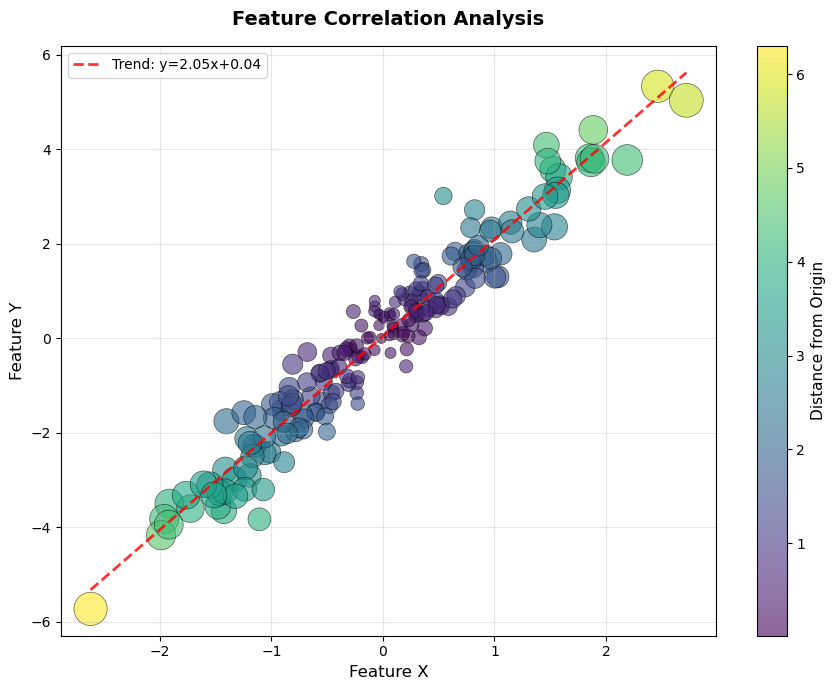

In [3]:
n_points = 200
x = np.random.randn(n_points)
y = 2 * x + np.random.randn(n_points) * 0.5
colors = np.sqrt(x**2 + y**2)
sizes = 50 + 200 * np.abs(x)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(x, y, c=colors, s=sizes, cmap='viridis',
                     alpha=0.6, edgecolors='black', linewidth=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Distance from Origin', fontsize=11)

ax.set_title('Feature Correlation Analysis', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Feature X', fontsize=12)
ax.set_ylabel('Feature Y', fontsize=12)
ax.grid(True, alpha=0.3)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(np.sort(x), p(np.sort(x)), 'r--', alpha=0.8, linewidth=2,
        label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
ax.legend()

plt.tight_layout()
plt.show()


## 4. Bar Plots {#bar}

Bar charts compare categorical values. They are useful for:
- Comparing model accuracy scores
- Displaying feature importance
- Showing class distributions
- Comparing grouped metrics

**Common types:**
- `ax.bar()` for vertical bars
- `ax.barh()` for horizontal bars
- Grouped bars for side-by-side comparison
- Stacked bars for composition


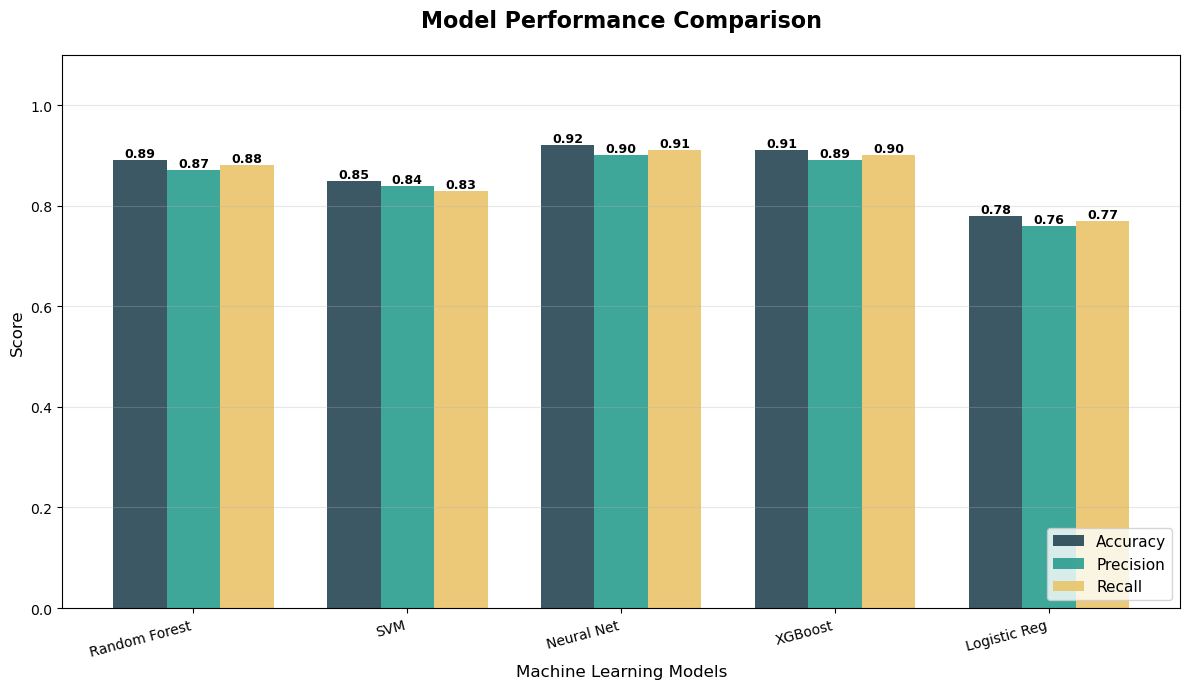

In [4]:
models = ['Random Forest', 'SVM', 'Neural Net', 'XGBoost', 'Logistic Reg']
accuracy = [0.89, 0.85, 0.92, 0.91, 0.78]
precision = [0.87, 0.84, 0.90, 0.89, 0.76]
recall = [0.88, 0.83, 0.91, 0.90, 0.77]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width, accuracy, width, label='Accuracy', color='#264653', alpha=0.9)
bars2 = ax.bar(x, precision, width, label='Precision', color='#2A9D8F', alpha=0.9)
bars3 = ax.bar(x + width, recall, width, label='Recall', color='#E9C46A', alpha=0.9)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Machine Learning Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


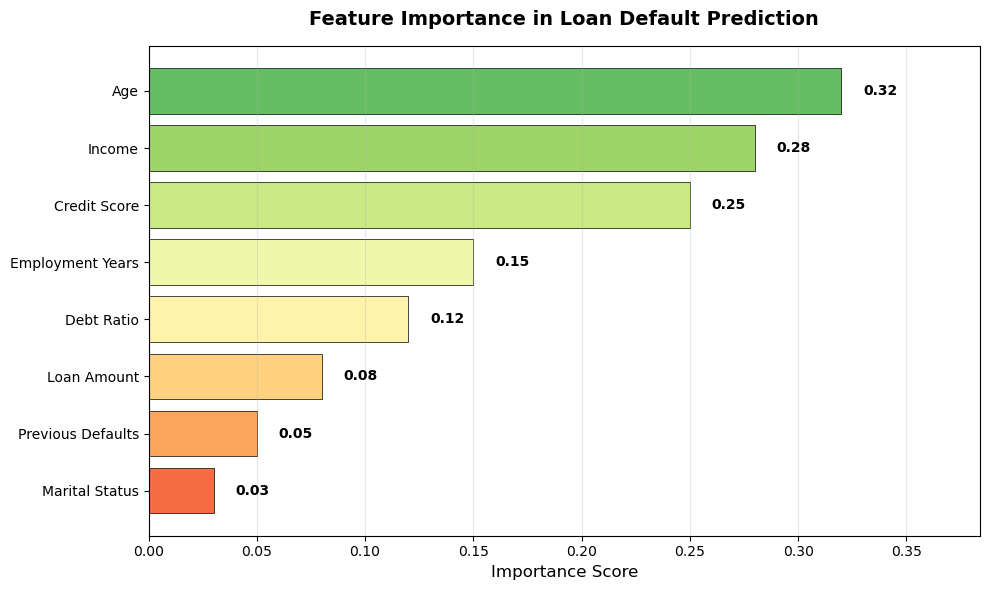

In [5]:
features = ['Age', 'Income', 'Credit Score', 'Employment Years',
            'Debt Ratio', 'Loan Amount', 'Previous Defaults', 'Marital Status']
importance = [0.32, 0.28, 0.25, 0.15, 0.12, 0.08, 0.05, 0.03]

sorted_idx = np.argsort(importance)
features_sorted = [features[i] for i in sorted_idx]
importance_sorted = [importance[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(features)))
bars = ax.barh(features_sorted, importance_sorted, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, importance_sorted):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Feature Importance in Loan Default Prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_xlim(0, max(importance) * 1.2)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Customization and Styling {#custom}

Professional plots depend on typography, spacing, color choices, and readability. Matplotlib allows deep customization through `rcParams` and per-axis styling.


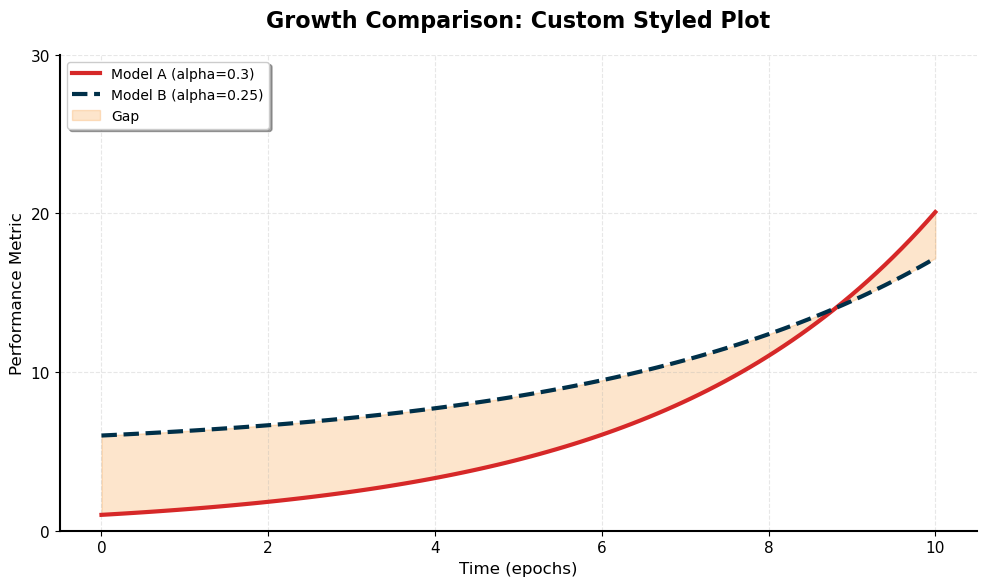

In [6]:
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10

fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, 10, 100)
y1 = np.exp(x * 0.3)
y2 = np.exp(x * 0.25) + 5

ax.plot(x, y1, color='#D62828', linewidth=3, label='Model A (alpha=0.3)')
ax.plot(x, y2, color='#003049', linewidth=3, linestyle='--', label='Model B (alpha=0.25)')
ax.fill_between(x, y1, y2, alpha=0.2, color='#F77F00', label='Gap')

ax.set_xticks(np.arange(0, 11, 2))
ax.set_yticks(np.arange(0, 40, 10))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_title('Growth Comparison: Custom Styled Plot', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Time (epochs)', fontsize=12)
ax.set_ylabel('Performance Metric', fontsize=12)
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()
plt.rcdefaults()


## 6. Multiple Subplots {#subplots}

Subplots let you place multiple charts in a single figure. Use `plt.subplots(nrows, ncols)` to create a grid of axes.


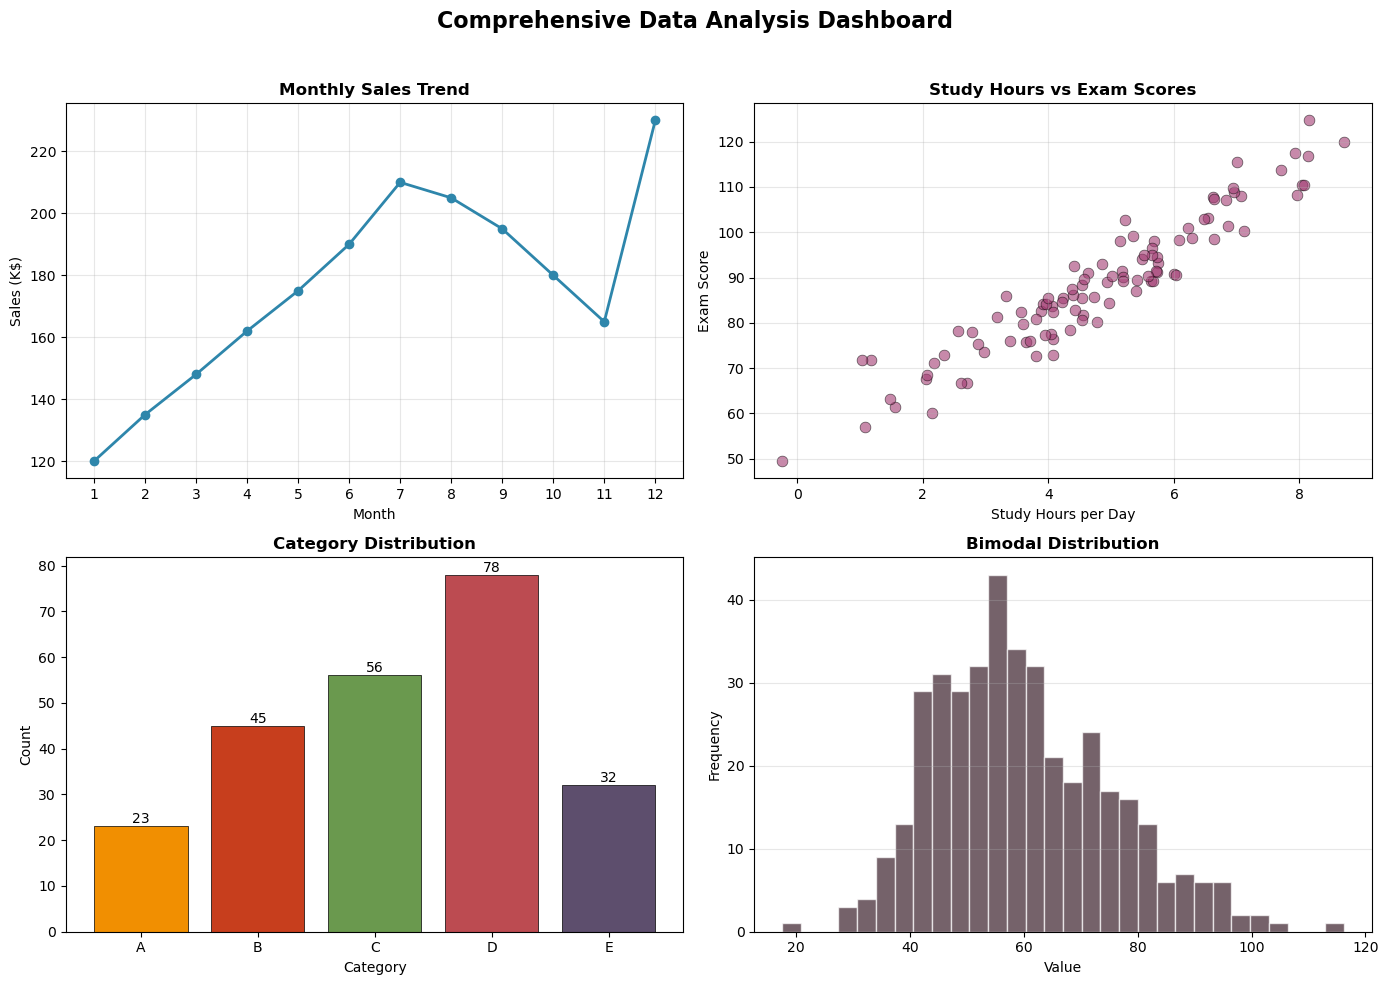

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comprehensive Data Analysis Dashboard', fontsize=16, fontweight='bold', y=0.98)

x = np.arange(1, 13)
sales = [120, 135, 148, 162, 175, 190, 210, 205, 195, 180, 165, 230]
axes[0, 0].plot(x, sales, marker='o', color='#2E86AB', linewidth=2, markersize=6)
axes[0, 0].set_title('Monthly Sales Trend', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Sales (K$)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(x)

np.random.seed(42)
study_hours = np.random.normal(5, 2, 100)
scores = 50 + 8 * study_hours + np.random.normal(0, 5, 100)
axes[0, 1].scatter(study_hours, scores, alpha=0.6, c='#A23B72', s=60, edgecolors='black', linewidth=0.5)
axes[0, 1].set_title('Study Hours vs Exam Scores', fontweight='bold')
axes[0, 1].set_xlabel('Study Hours per Day')
axes[0, 1].set_ylabel('Exam Score')
axes[0, 1].grid(True, alpha=0.3)

categories = ['A', 'B', 'C', 'D', 'E']
values = [23, 45, 56, 78, 32]
colors = ['#F18F01', '#C73E1D', '#6A994E', '#BC4B51', '#5D4E6D']
bars = axes[1, 0].bar(categories, values, color=colors, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Category Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2.0, height,
                    f'{int(height)}', ha='center', va='bottom')

data = np.concatenate([np.random.normal(50, 10, 200), np.random.normal(70, 15, 200)])
axes[1, 1].hist(data, bins=30, color='#3B1F2B', alpha=0.7, edgecolor='white')
axes[1, 1].set_title('Bimodal Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 7. Saving Figures {#save}

Use `plt.savefig()` to export plots for reports, dashboards, or presentations. Vector formats such as PDF and SVG are ideal for scalability, while high-DPI PNG works well for the web.


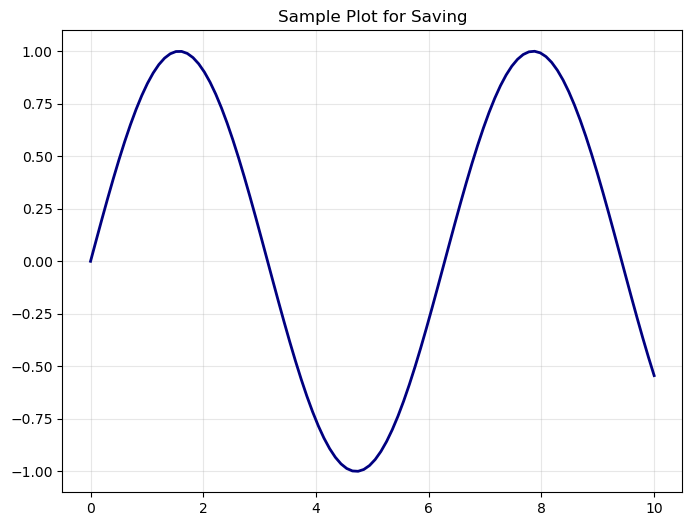

To save: plt.savefig('filename.png', dpi=300, bbox_inches='tight')


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), color='navy', linewidth=2)
ax.set_title('Sample Plot for Saving')
ax.grid(True, alpha=0.3)

# plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
# plt.savefig('my_plot.pdf', bbox_inches='tight')
# plt.savefig('my_plot.svg', bbox_inches='tight')

plt.show()

print("To save: plt.savefig('filename.png', dpi=300, bbox_inches='tight')")


## 8. Best Practices {#best}

1. Label axes clearly, including units when needed.
2. Keep titles descriptive but concise.
3. Use readable color palettes.
4. Add legends when multiple series are shown.
5. Keep styling consistent across related plots.
6. Save high-resolution figures for reports.
7. Remove unnecessary visual clutter.
8. Highlight key points with annotations when useful.


## 9. Real ML Examples {#ml}

These examples show practical Matplotlib use cases in machine learning workflows.


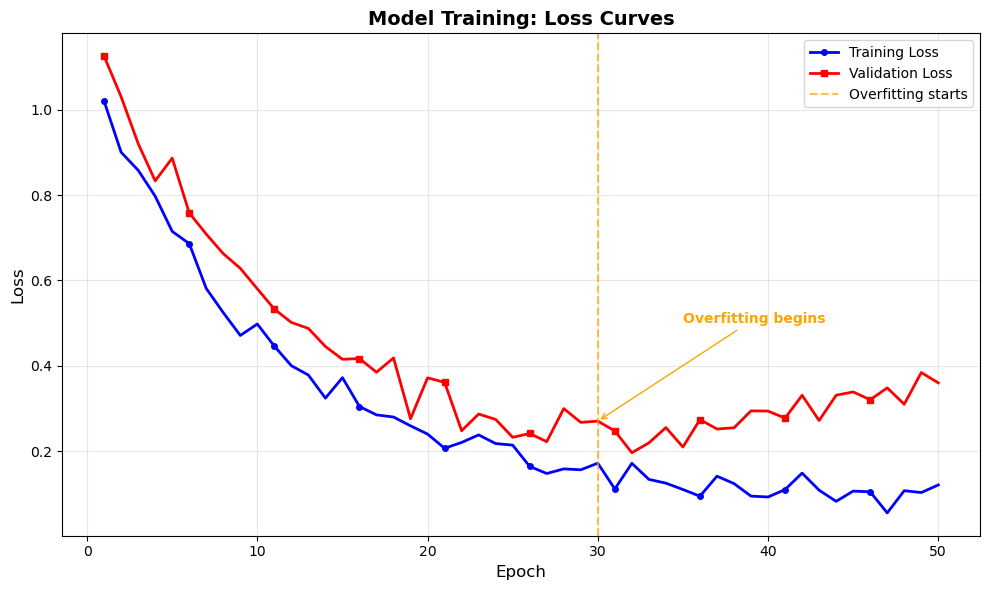

In [9]:
# Example 1: Training and validation loss curves
epochs = np.arange(1, 51)
train_loss = 1.0 * np.exp(-epochs / 10) + 0.1 + np.random.normal(0, 0.02, 50)
val_loss = 1.0 * np.exp(-epochs / 12) + 0.15 + np.random.normal(0, 0.03, 50)
val_loss[30:] += np.linspace(0, 0.2, 20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss', marker='o', markevery=5, markersize=4)
ax.plot(epochs, val_loss, 'r-', linewidth=2, label='Validation Loss', marker='s', markevery=5, markersize=4)
ax.axvline(x=30, color='orange', linestyle='--', alpha=0.7, label='Overfitting starts')
ax.annotate('Overfitting begins', xy=(30, val_loss[29]), xytext=(35, 0.5),
            arrowprops=dict(arrowstyle='->', color='orange'),
            fontsize=10, color='orange', fontweight='bold')
ax.set_title('Model Training: Loss Curves', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


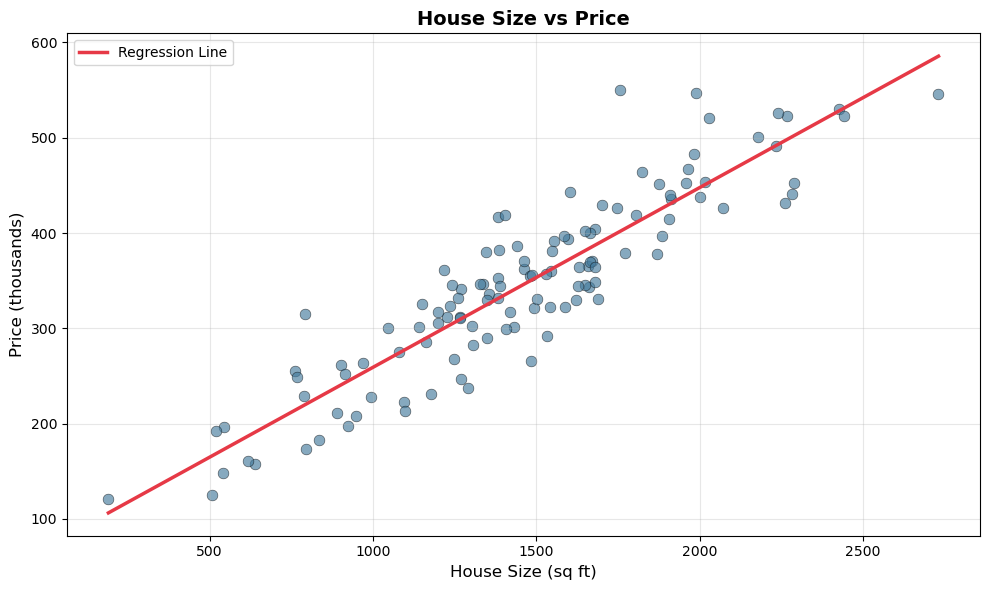

In [10]:
# Example 2: Feature vs target with regression line
np.random.seed(42)
house_size = np.random.normal(1500, 500, 120)
price = 80 + 0.18 * house_size + np.random.normal(0, 40, 120)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(house_size, price, alpha=0.65, s=60, c='#457B9D', edgecolors='black', linewidth=0.4)
z = np.polyfit(house_size, price, 1)
p = np.poly1d(z)
x_sorted = np.sort(house_size)
ax.plot(x_sorted, p(x_sorted), color='#E63946', linewidth=2.5, label='Regression Line')
ax.set_title('House Size vs Price', fontsize=14, fontweight='bold')
ax.set_xlabel('House Size (sq ft)', fontsize=12)
ax.set_ylabel('Price (thousands)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


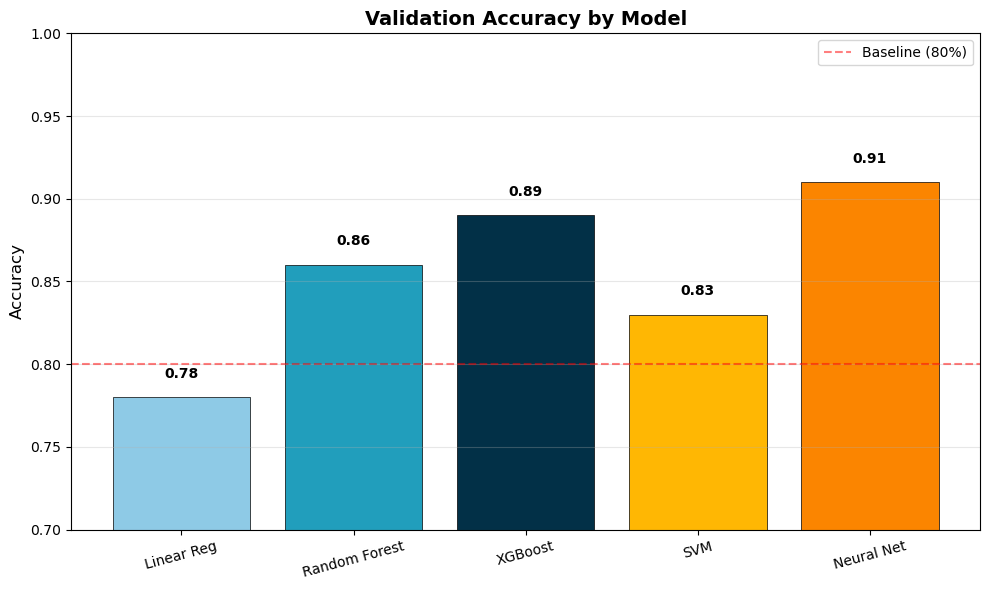

In [11]:
# Example 3: Model accuracy comparison
models = ['Linear Reg', 'Random Forest', 'XGBoost', 'SVM', 'Neural Net']
scores = [0.78, 0.86, 0.89, 0.83, 0.91]
colors = ['#8ECAE6', '#219EBC', '#023047', '#FFB703', '#FB8500']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, scores, color=colors, edgecolor='black', linewidth=0.5)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2.0, score + 0.01,
            f'{score:.2f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Validation Accuracy by Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xticks(np.arange(len(models)))
ax.set_xticklabels(models, rotation=15)
ax.set_ylim(0.7, 1.0)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Baseline (80%)')
ax.legend()
plt.tight_layout()
plt.show()


## Hands-On Exercises {#exercises}

Practice these exercises to strengthen your Matplotlib skills.


### Exercise 1: Basic Line Plot
Create a line plot of the first 20 Fibonacci numbers. Add a title, axis labels, and a grid.


In [12]:
# your code here


### Exercise 2: Customized Line Plot
Plot `y = x^2` and `y = x^3` for `x` from 0 to 5. Use different colors, linestyles, and markers, then add a legend.


In [13]:
# your code here


### Exercise 3: Scatter with Color Mapping
Create a scatter plot of 100 random points. Color the points by distance from the origin and add a colorbar.


In [14]:
# your code here


### Exercise 4: Bar Chart of Categories
Create a bar chart showing letter frequencies in a name. Use different colors and label each bar.


In [15]:
# your code here


### Exercise 5: Horizontal Bar Chart
Create a horizontal bar chart for five programming languages using fictional popularity scores.


In [16]:
# your code here


### Exercise 6: Grouped Bar Chart
Create a grouped bar chart comparing quarterly sales for three products, including error bars.


In [17]:
# your code here


### Exercise 7: Multiple Subplots
Create a 1x3 subplot layout with a sine wave, a histogram, and a scatter plot.


In [18]:
# your code here


### Exercise 8: Training Loss Curves
Simulate training and validation loss over 30 epochs and annotate the point where overfitting begins.


In [19]:
# your code here


### Exercise 9: Feature Importance Visualization
Create a professional horizontal bar chart showing feature importance for eight features.


In [20]:
# your code here


### Exercise 10: Combined Plot Types
Create one figure with a line plot for trend and a scatter plot for actual observations on the same axes.


In [21]:
# your code here


### Exercise 11: Publication-Ready Plot
Create a polished figure with custom font sizes, clean spines, thoughtful color choices, and commented `savefig` code.


In [22]:
# your code here


## Solutions {#solutions}

Review these only after you attempt the exercises.


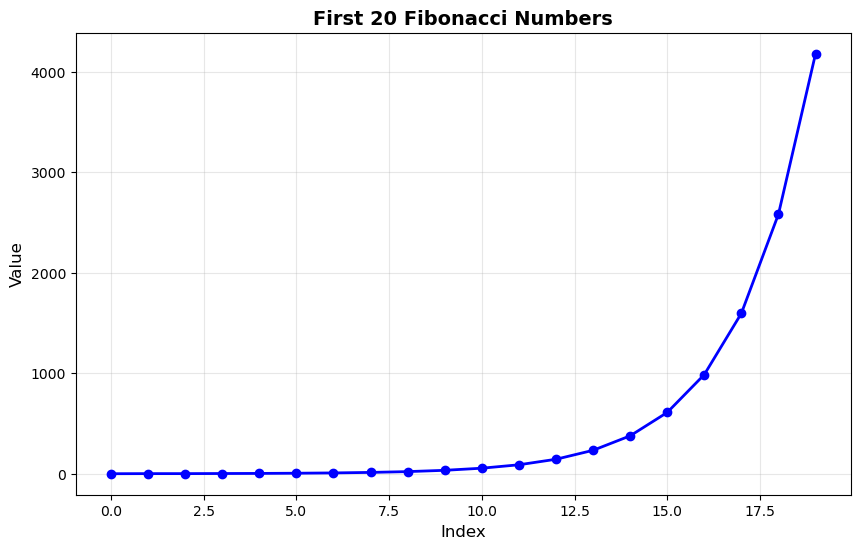

In [23]:
# Solution 1
def fibonacci(n):
    fib = [0, 1]
    for i in range(2, n):
        fib.append(fib[i - 1] + fib[i - 2])
    return fib

fib_nums = fibonacci(20)
x = range(20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, fib_nums, 'bo-', linewidth=2, markersize=6)
ax.set_title('First 20 Fibonacci Numbers', fontsize=14, fontweight='bold')
ax.set_xlabel('Index', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()


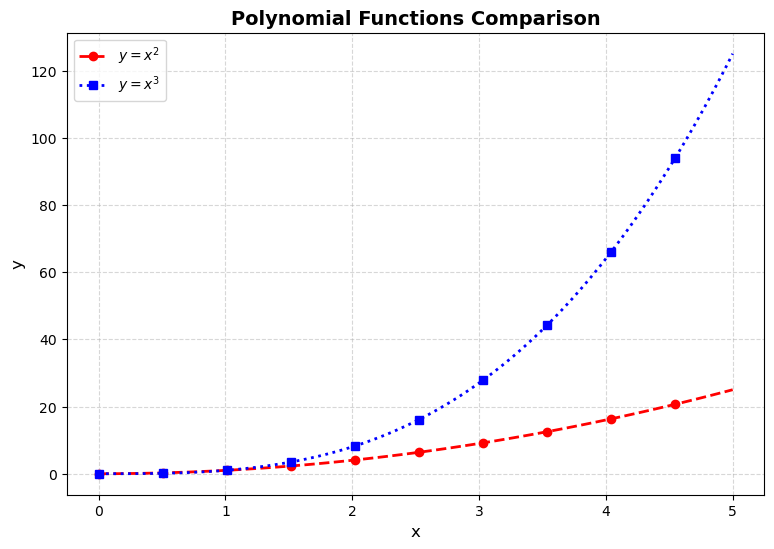

In [24]:
# Solution 2
x = np.linspace(0, 5, 100)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x, x**2, 'r--', linewidth=2, marker='o', markevery=10, label='$y = x^2$')
ax.plot(x, x**3, 'b:', linewidth=2, marker='s', markevery=10, label='$y = x^3$')
ax.set_title('Polynomial Functions Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()
